In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [24]:
df = pd.read_csv(
    r"C:\Users\aggar\Downloads\DataCoSupplyChainDataset.csv\DataCoSupplyChainDataset.csv",
    encoding='latin1'
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [25]:
df.shape

(180519, 53)

In [26]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [28]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [29]:
df.drop(columns=['Product Description', 'Order Zipcode'], inplace=True)

In [31]:
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

In [32]:
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
    df['Customer Zipcode'].mode()[0]
)

In [33]:
df[['Customer Lname', 'Customer Zipcode']].isnull().sum()

Customer Lname      0
Customer Zipcode    0
dtype: int64

In [34]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [35]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [36]:
df[['order date (DateOrders)',
    'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [37]:
df['Order Year'] = df['order date (DateOrders)'].dt.year
df['Order Month'] = df['order date (DateOrders)'].dt.month
df['Order Month Name'] = df['order date (DateOrders)'].dt.month_name()
df['Order Quarter'] = df['order date (DateOrders)'].dt.quarter
df['Order Day'] = df['order date (DateOrders)'].dt.day_name()

In [38]:
df[['Order Year',
    'Order Month',
    'Order Month Name',
    'Order Quarter',
    'Order Day']].head()

,Order Year,Order Month,Order Month Name,Order Quarter,Order Day
0,2018,1,January,1,Wednesday
1,2018,1,January,1,Saturday
2,2018,1,January,1,Saturday
3,2018,1,January,1,Saturday
4,2018,1,January,1,Saturday


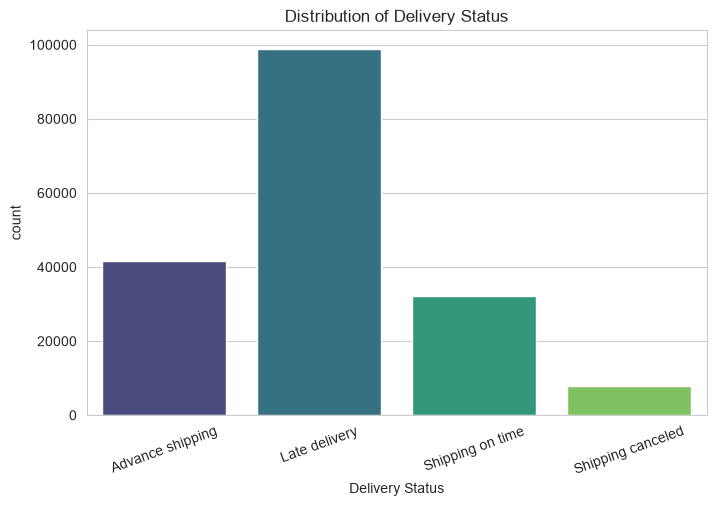

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Delivery Status',
    hue='Delivery Status',
    palette='viridis',
    legend=False
)

plt.title("Distribution of Delivery Status")
plt.xticks(rotation=20)

plt.show()

In [40]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

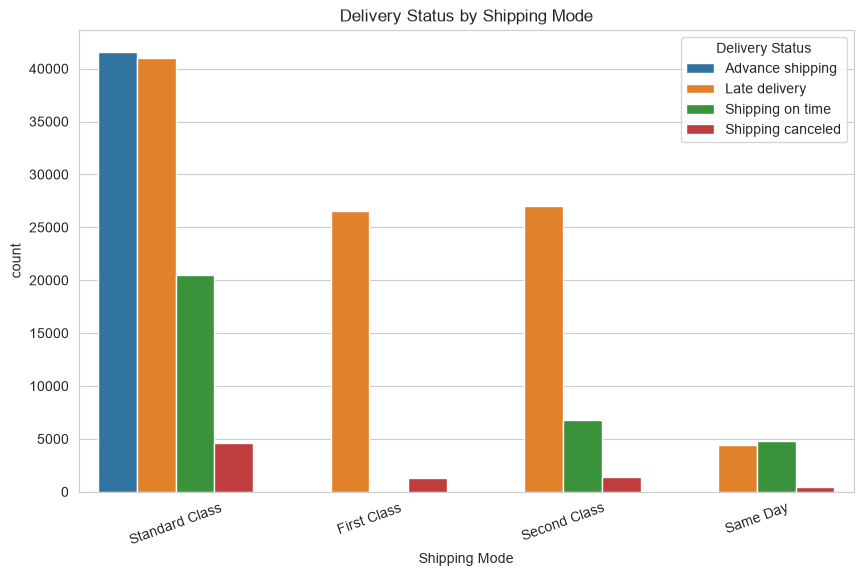

In [41]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Shipping Mode',
    hue='Delivery Status'
)

plt.title("Delivery Status by Shipping Mode")
plt.xticks(rotation=20)

plt.show()

In [42]:
pd.crosstab(df['Shipping Mode'], df['Delivery Status'])

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0,26513,1301,0
Same Day,0,4454,444,4839
Second Class,0,26987,1410,6819
Standard Class,41592,41023,4599,20538


In [43]:
delivery_pct = pd.crosstab(
    df['Shipping Mode'],
    df['Delivery Status'],
    normalize='index'
) * 100

delivery_pct.round(2)

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.0,95.32,4.68,0.00
Same Day,0.0,45.74,4.56,49.70
Second Class,0.0,76.63,4.00,19.36
Standard Class,38.6,38.07,4.27,19.06


In [44]:
df.groupby('Shipping Mode')[
    ['Days for shipping (real)', 'Days for shipment (scheduled)']
].mean().round(2)

,Days for shipping (real),Days for shipment (scheduled)
Shipping Mode,,
First Class,2.00,1.0
Same Day,0.48,0.0
Second Class,3.99,2.0
Standard Class,4.00,4.0


In [45]:
df.groupby('Shipping Mode')[
    ['Days for shipping (real)', 'Days for shipment (scheduled)']
].mean().round(2)

,Days for shipping (real),Days for shipment (scheduled)
Shipping Mode,,
First Class,2.00,1.0
Same Day,0.48,0.0
Second Class,3.99,2.0
Standard Class,4.00,4.0


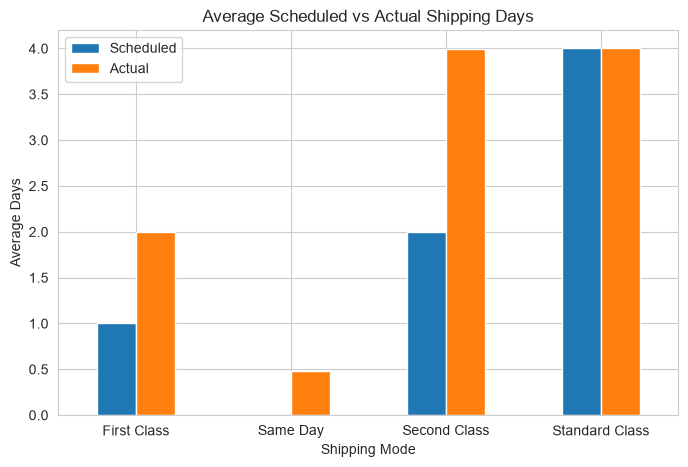

In [46]:
shipping_compare = df.groupby('Shipping Mode')[
    ['Days for shipment (scheduled)', 'Days for shipping (real)']
].mean().round(2)

shipping_compare.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Scheduled vs Actual Shipping Days")
plt.ylabel("Average Days")
plt.xticks(rotation=0)
plt.legend(['Scheduled', 'Actual'])

plt.show()

In [47]:
df['Shipping Delay (Days)'] = (
    df['Days for shipping (real)']
    - df['Days for shipment (scheduled)']
)

df.groupby('Shipping Mode')['Shipping Delay (Days)'].mean().round(2)

Shipping Mode
First Class       1.00
Same Day          0.48
Second Class      1.99
Standard Class   -0.00
Name: Shipping Delay (Days), dtype: float64

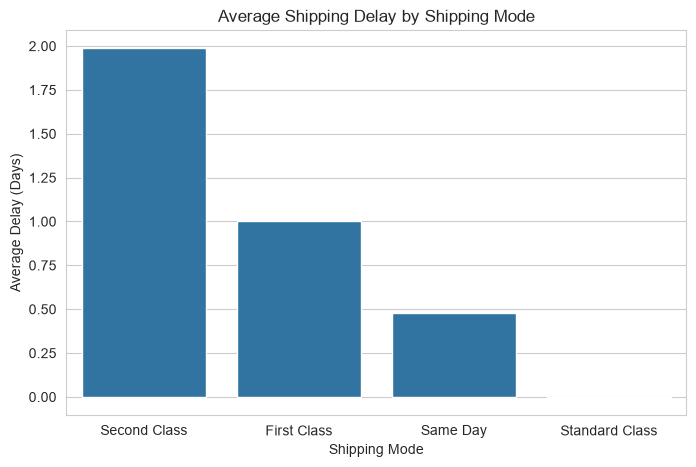

In [48]:
shipping_delay = (
    df.groupby('Shipping Mode')['Shipping Delay (Days)']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_delay.index,
    y=shipping_delay.values
)

plt.title("Average Shipping Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay (Days)")

plt.show()

In [49]:
top_categories = (
    df.groupby('Category Name')
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Order Profit Per Order', 'sum'),
          Orders=('Order Id', 'count')
      )
      .sort_values('Total_Sales', ascending=False)
)

top_categories.head(10)

,Total_Sales,Total_Profit,Orders
Category Name,,,
Fishing,6.929654e+06,756220.767190,17325
Cleats,4.431943e+06,494636.919791,24551
Camping & Hiking,4.118426e+06,427455.568106,13729
Cardio Equipment,3.694843e+06,383011.098485,12487
Women's Apparel,3.147800e+06,350421.029567,21035
Water Sports,3.113845e+06,325146.960038,15540
Men's Footwear,2.891758e+06,311902.820214,22246
Indoor/Outdoor Games,2.888994e+06,318451.430554,19298
Shop By Sport,1.309522e+06,129813.960315,10984


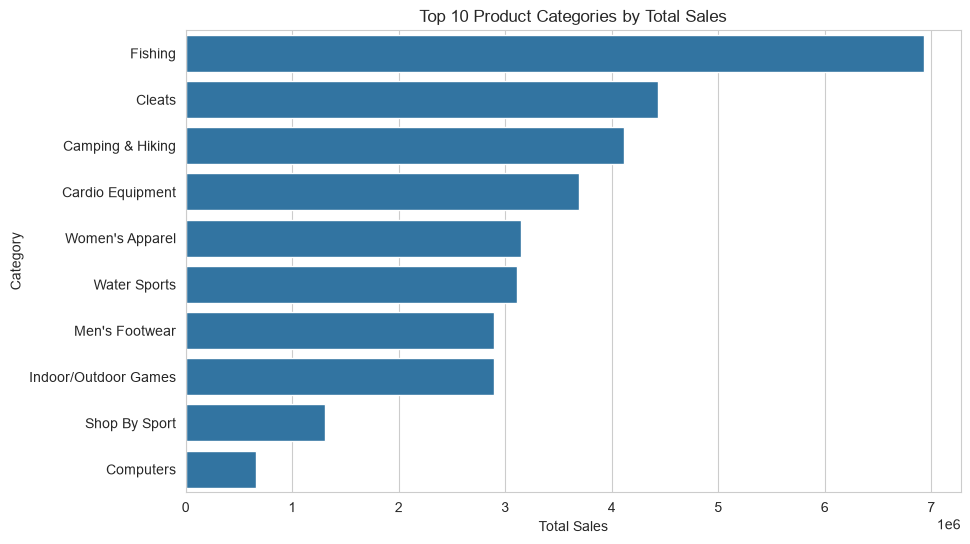

In [50]:
top10_sales = top_categories.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_sales,
    x='Total_Sales',
    y=top10_sales.index
)

plt.title("Top 10 Product Categories by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()

In [52]:
category_profit = df.groupby('Category Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Order Id', 'count')
)

category_profit['Profit per Order'] = (
    category_profit['Profit'] /
    category_profit['Orders']
)

category_profit.sort_values(
    'Profit per Order',
    ascending=False
).head(10)

,Sales,Profit,Orders,Profit per Order
Category Name,,,,
Computers,6.630000e+05,69656.810171,442,157.594593
Garden,2.577687e+05,33443.010106,484,69.097128
Crafts,2.233563e+05,25531.170060,484,52.750351
Cameras,2.676077e+05,30289.799946,592,51.165203
Fishing,6.929654e+06,756220.767190,17325,43.649106
Children's Clothing,2.328292e+05,27178.099597,652,41.684202
Sporting Goods,1.170068e+05,12518.610119,357,35.066135
Music,1.131221e+05,14436.319923,434,33.263410
Camping & Hiking,4.118426e+06,427455.568106,13729,31.135230


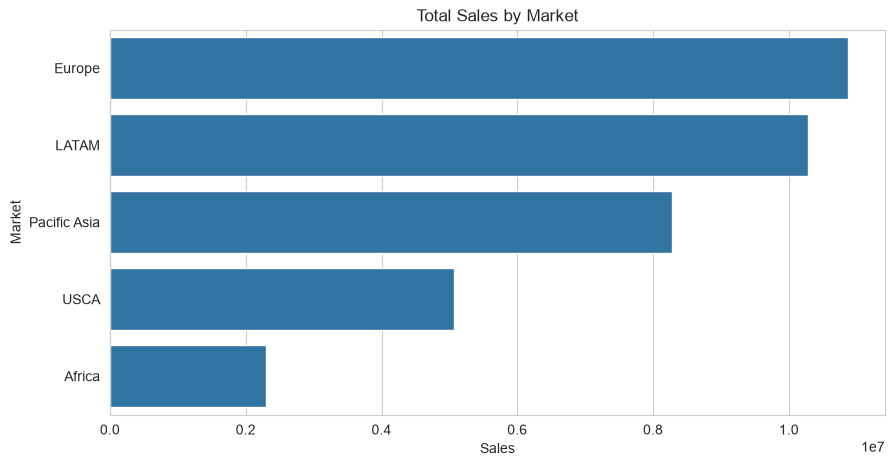

In [55]:
market_sales = (
    df.groupby('Market')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=market_sales.values,
    y=market_sales.index
)

plt.title("Total Sales by Market")
plt.xlabel("Sales")
plt.ylabel("Market")

plt.show()


In [56]:
market_sales

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64

In [57]:
market_profit = (
    df.groupby('Market')['Order Profit Per Order']
      .sum()
      .sort_values(ascending=False)
)

market_profit

Market
Europe          1.169443e+06
LATAM           1.123322e+06
Pacific Asia    8.577534e+05
USCA            5.643138e+05
Africa          2.520712e+05
Name: Order Profit Per Order, dtype: float64

In [59]:
market_analysis = df.groupby('Market').agg(
    Sales=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum')
)

market_analysis['Profit Margin (%)'] = (
    market_analysis['Profit'] / market_analysis['Sales']
) * 100

market_analysis.round(2)

,Sales,Profit,Profit Margin (%)
Market,,,
Africa,2294452.93,252071.18,10.99
Europe,10872396.80,1169442.96,10.76
LATAM,10277612.84,1123321.61,10.93
Pacific Asia,8273743.74,857753.44,10.37
USCA,5066528.71,564313.78,11.14


In [61]:
segment_analysis = df.groupby('Customer Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Order Id', 'count')
).sort_values('Sales', ascending=False)

segment_analysis

,Sales,Profit,Orders
Customer Segment,,,
Consumer,1.909579e+07,2.073488e+06,93504
Corporate,1.116841e+07,1.202575e+06,54789
Home Office,6.520538e+06,6.908403e+05,32226


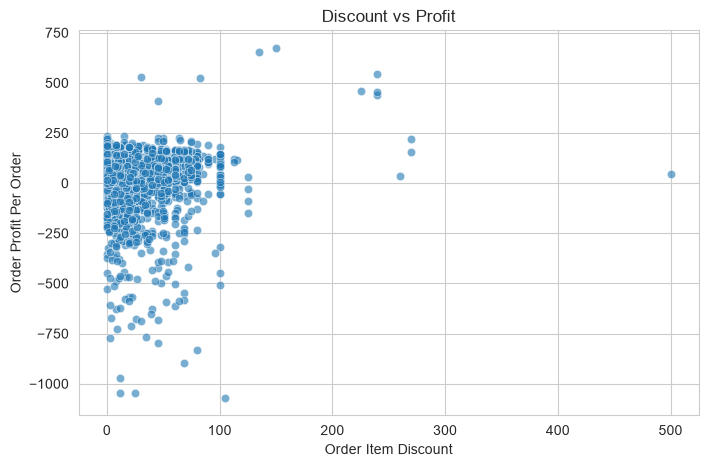

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Order Item Discount',
    y='Order Profit Per Order',
    alpha=0.6
)

plt.title("Discount vs Profit")

plt.show()

In [63]:
df[['Order Item Discount',
    'Order Profit Per Order']].corr()

,Order Item Discount,Order Profit Per Order
Order Item Discount,1.000000,0.064756
Order Profit Per Order,0.064756,1.000000
